# Cannibalization Detection

S-Learner: for every promoted product A and candidate affected product B, predicts B's quantity with and without A promoted.
`cannibalization = max(0, y_control - y_treatment)`.

In [1]:
import json
import os
import time
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw" / "transaction_data.csv").exists():
    ROOT = next(p for p in ROOT.parents if (p / "data" / "raw" / "transaction_data.csv").exists())
RAW = ROOT / "data" / "raw"
BASE = ROOT / "outputs" / "baseline_engine"
EMB = ROOT / "outputs" / "product_embeddings"
SMOKE = os.environ.get("CANNIBALIZATION_SMOKE", "") == "1"
OUT = ROOT / "outputs" / ("cannibalization_smoke" if SMOKE else "cannibalization")
OUT.mkdir(parents=True, exist_ok=True)

FIRST_TEST_WEEK, LAST_TEST_WEEK = 89, 101
TRAIN_END = 78
RESID_END = 88
MODEL_SPLIT_WEEK = 97
TOP_SUBS, MAX_CANDIDATES = 10, 12
COSINE_MIN, EVIDENCE_COSINE = 0.35, 0.45
CALIB_LO, CALIB_HI = 79, 88
EMB_DIMS = 8 if SMOKE else 64
SEED = 42
np.random.seed(SEED)

In [2]:
tx = pd.read_csv(RAW / "transaction_data.csv", usecols=["household_key", "BASKET_ID", "DAY", "PRODUCT_ID",
                                                        "QUANTITY", "SALES_VALUE", "STORE_ID", "RETAIL_DISC", "WEEK_NO"])
product = pd.read_csv(RAW / "product.csv")

try:
    causal = pd.read_parquet(ROOT / "data" / "processed" / "causal_weekly.parquet")
except FileNotFoundError:
    causal_raw = pd.read_csv(RAW / "causal_data.csv", usecols=["PRODUCT_ID", "STORE_ID", "WEEK_NO", "display", "mailer"])
    causal_raw["mailer_on"] = causal_raw["mailer"].astype(str).ne("0").astype(int)
    causal = (causal_raw.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
              .agg(display_share=("display", lambda s: (s > 0).mean()), mailer_share=("mailer_on", "mean")))
    causal.to_parquet(ROOT / "data" / "processed" / "causal_weekly.parquet", index=False)
causal = causal.rename(columns={"display_share": "display", "mailer_share": "mailer"})

campaign_desc = pd.read_csv(RAW / "campaign_desc.csv")
day_week = tx.groupby("DAY")["WEEK_NO"].agg(lambda s: s.mode().iloc[0])
max_day = int(max(tx["DAY"].max(), campaign_desc[["START_DAY", "END_DAY"]].to_numpy().max()))
day_week = day_week.reindex(range(1, max_day + 1)).ffill().astype(int)
campaign_desc["start_week"] = campaign_desc["START_DAY"].map(day_week).astype(int)
campaign_desc["end_week"] = campaign_desc["END_DAY"].map(day_week).astype(int)
coupon = pd.read_csv(RAW / "coupon.csv", usecols=["PRODUCT_ID", "CAMPAIGN"]).drop_duplicates()
pc = coupon.merge(campaign_desc[["CAMPAIGN", "DESCRIPTION", "start_week", "end_week"]], on="CAMPAIGN")
pc = pc[(pc["start_week"] <= LAST_TEST_WEEK) & (pc["end_week"] >= FIRST_TEST_WEEK)]
n_weeks = (pc["end_week"] - pc["start_week"] + 1).to_numpy()
campaign_weekly = pd.DataFrame({
    "PRODUCT_ID": np.repeat(pc["PRODUCT_ID"].to_numpy(), n_weeks),
    "WEEK_NO": np.concatenate([np.arange(s, e + 1) for s, e in zip(pc["start_week"], pc["end_week"])]),
    "TYPE": np.repeat(pc["DESCRIPTION"].to_numpy(), n_weeks),
})
campaign_weekly["TYPE_code"] = campaign_weekly["TYPE"].map({"TypeA": 1, "TypeB": 2, "TypeC": 3}).fillna(0)
campaign_weekly = (campaign_weekly.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
                   .agg(n_campaigns=("TYPE", "count"), campaign_type=("TYPE_code", "max"))
                   .assign(has_campaign=1))

cache = None
if SMOKE:
    cache = next((p for p in [OUT / "base_weekly.parquet", ROOT / "outputs" / "cannibalization" / "base_weekly.parquet"]
                  if p.exists()), None)
if cache is not None:
    base_weekly = pd.read_parquet(cache)
else:
    fl = json.loads((BASE / "feature_list.json").read_text())
    FEATURES, CATS = fl["features"], fl["cat_cols_encoded"]
    panel = pd.read_parquet(BASE / "panel.parquet")
    X = panel[FEATURES].copy()
    for c in CATS:
        X[c] = X[c].astype("category")
    stage1 = joblib.load(BASE / "model_stage1.pkl")
    stage2 = joblib.load(BASE / "model_stage2.pkl")
    panel["baseline_qty"] = stage1.predict_proba(X)[:, 1] * stage2.predict(X)
    base_weekly = panel.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["baseline_qty"].sum()
    base_weekly.to_parquet(OUT / "base_weekly.parquet", index=False)
    del panel, X
print("base_weekly:", base_weekly.shape)

base_weekly: (266337, 3)


In [3]:
panel_products = pd.Index(base_weekly["PRODUCT_ID"].unique(), name="PRODUCT_ID")
txw = tx.assign(promo=(tx["RETAIL_DISC"] < 0))
txw["unit_price"] = txw["SALES_VALUE"] / txw["QUANTITY"].where(txw["QUANTITY"] > 0)
txw.loc[txw["unit_price"] < 0, "unit_price"] = np.nan

pw = txw[txw["PRODUCT_ID"].isin(panel_products)].groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False).agg(
    qty=("QUANTITY", "sum"), promo=("promo", "max"), disc_min=("RETAIL_DISC", "min"), price=("unit_price", "mean"))
disc_depth = (txw[txw["promo"]][["PRODUCT_ID", "WEEK_NO", "RETAIL_DISC"]]
              .groupby(["PRODUCT_ID", "WEEK_NO"])["RETAIL_DISC"].mean().rename("disc_depth"))
pw = pw.merge(disc_depth, on=["PRODUCT_ID", "WEEK_NO"], how="left")
pw["disc_depth"] = (-pw["disc_depth"]).fillna(0.0).clip(lower=0.0)
pw = pw.merge(base_weekly, on=["PRODUCT_ID", "WEEK_NO"], how="left")
pw = pw.merge(causal, on=["PRODUCT_ID", "WEEK_NO"], how="left")
pw = pw.merge(campaign_weekly, on=["PRODUCT_ID", "WEEK_NO"], how="left")
for c in ["display", "mailer", "has_campaign", "n_campaigns", "campaign_type"]:
    pw[c] = pw[c].fillna(0)

pw = pw.sort_values(["PRODUCT_ID", "WEEK_NO"]).reset_index(drop=True)
pw["qty_lag1"] = pw.groupby("PRODUCT_ID")["qty"].shift(1)
pw["rmean4"] = pw.groupby("PRODUCT_ID")["qty_lag1"].transform(lambda s: s.rolling(4, min_periods=1).mean())

pre = pw[pw["WEEK_NO"] <= TRAIN_END]
pw = pw.merge(pre.groupby("PRODUCT_ID", as_index=False).agg(
    total_qty_78=("qty", "sum"), promo_freq=("promo", "mean")), on="PRODUCT_ID", how="left")

resid = pw[(pw["WEEK_NO"] <= RESID_END) & (pw["promo"] == 0)].copy()
resid["resid"] = resid["qty"] - resid["baseline_qty"]
pw = pw.merge(resid.groupby("PRODUCT_ID")["resid"].std().rename("resid_std"), on="PRODUCT_ID", how="left")
pw["resid_std"] = pw["resid_std"].fillna(resid["resid"].std())

cal_hold = pw[(pw["WEEK_NO"].between(CALIB_LO, CALIB_HI)) & (pw["promo"] == 0)].groupby("PRODUCT_ID").agg(
    actual=("qty", "sum"), pred=("baseline_qty", "sum"))
cal_train = pw[(pw["WEEK_NO"] <= TRAIN_END) & (pw["promo"] == 0)].groupby("PRODUCT_ID").agg(
    actual=("qty", "sum"), pred=("baseline_qty", "sum"))
calib = (cal_hold["actual"] / cal_hold["pred"]).fillna(cal_train["actual"] / cal_train["pred"])
calib = calib.replace([np.inf, -np.inf], np.nan).fillna(1.0)
pw = pw.merge(calib.rename("calib_factor"), on="PRODUCT_ID", how="left")
pw["calib_factor"] = pw["calib_factor"].fillna(1.0)
pw["baseline_cal"] = pw["baseline_qty"] * pw["calib_factor"]

price_med = pw[pw["WEEK_NO"] <= TRAIN_END].groupby("PRODUCT_ID")["price"].median()
pw["price"] = pw["price"].fillna(pw["PRODUCT_ID"].map(price_med))
pw["price"] = pw["price"].fillna(pw[pw["WEEK_NO"] <= TRAIN_END]["price"].median()).clip(lower=0.0)

pw = pw[pw["WEEK_NO"].between(1, LAST_TEST_WEEK)].reset_index(drop=True)
print("product-week rows:", len(pw), "| products:", pw["PRODUCT_ID"].nunique())

product-week rows: 198376 | products: 2637


In [4]:
top = pd.read_parquet(EMB / "top_k_substitutes.parquet")
subs = pd.concat([
    pd.DataFrame({
        "promoted_product": top["PRODUCT_ID"],
        "affected_product": top[f"substitute_{r}"],
        "cosine_sim": top[f"substitute_similarity_{r}"],
        "substitute_score": top[f"substitute_score_{r}"],
        "substitute_rank": r,
    })
    for r in range(1, TOP_SUBS + 1)
], ignore_index=True).dropna(subset=["affected_product"])
subs["affected_product"] = subs["affected_product"].astype(np.int64)

sim = pd.read_parquet(EMB / "product_similarity.parquet",
                      columns=["PRODUCT_ID", "SIMILAR_PRODUCT_ID", "embedding_cosine", "sub_commodity_match",
                               "commodity_match", "department_match", "brand_match", "manufacturer_match",
                               "metadata_similarity", "basket_jaccard", "basket_cosine",
                               "household_jaccard", "store_jaccard"])
sim_wide = sim.drop_duplicates(["PRODUCT_ID", "SIMILAR_PRODUCT_ID"]).rename(
    columns={"PRODUCT_ID": "promoted_product", "SIMILAR_PRODUCT_ID": "affected_product"})
subs = subs.merge(sim_wide, on=["promoted_product", "affected_product"], how="left")

extra = sim_wide[(sim_wide["sub_commodity_match"] == 1) & (sim_wide["embedding_cosine"] >= COSINE_MIN)].copy()
extra["substitute_rank"] = TOP_SUBS + 1
extra["substitute_score"] = extra["embedding_cosine"]
subs = pd.concat([subs, extra], ignore_index=True).drop_duplicates(["promoted_product", "affected_product"])

subs = subs[(subs["promoted_product"].isin(panel_products)) & (subs["affected_product"].isin(panel_products))
            & (subs["promoted_product"] != subs["affected_product"])]
evidence = (subs["department_match"] == 1) | (subs["basket_jaccard"].fillna(0) > 0) | (subs["cosine_sim"] >= EVIDENCE_COSINE)
subs = subs[evidence].sort_values(["promoted_product", "substitute_score"], ascending=[True, False])
subs["cand_rank"] = subs.groupby("promoted_product").cumcount() + 1
subs = subs[subs["cand_rank"] <= MAX_CANDIDATES].reset_index(drop=True)
if SMOKE:
    subs = subs[subs["promoted_product"].isin(subs["promoted_product"].unique()[:40])].reset_index(drop=True)

q78 = pw[pw["WEEK_NO"] <= TRAIN_END].pivot(index="PRODUCT_ID", columns="WEEK_NO", values="qty").reindex(
    index=panel_products, columns=range(1, TRAIN_END + 1)).fillna(0)
with np.errstate(invalid="ignore"):
    corr_mat = np.corrcoef(q78.to_numpy())
corr_mat[np.isnan(corr_mat)] = 0.0
pid_to_row = {p: i for i, p in enumerate(q78.index)}
subs["demand_corr"] = [corr_mat[pid_to_row[a], pid_to_row[b]]
                       for a, b in zip(subs["promoted_product"], subs["affected_product"])]
tot = q78.sum(axis=1)
subs = subs.merge(tot.rename("total_a"), left_on="promoted_product", right_index=True, how="left")
subs = subs.merge(tot.rename("total_b"), left_on="affected_product", right_index=True, how="left")
subs["sales_scale_log_ratio"] = np.log((subs["total_b"] + 1) / (subs["total_a"] + 1))
subs = subs.drop(columns=["total_a", "total_b"])
pfreq = pre.groupby("PRODUCT_ID")["promo"].mean()
subs = subs.merge(pfreq.rename("promo_freq_A"), left_on="promoted_product", right_index=True, how="left")
subs = subs.merge(pfreq.rename("promo_freq_B"), left_on="affected_product", right_index=True, how="left")

pair_cols = ["cosine_sim", "sub_commodity_match", "commodity_match", "department_match", "brand_match",
             "manufacturer_match", "metadata_similarity", "basket_jaccard", "basket_cosine",
             "household_jaccard", "store_jaccard"]
subs[pair_cols] = subs[pair_cols].fillna(0)

emb = pd.read_parquet(EMB / "product_embeddings.parquet",
                      columns=["PRODUCT_ID"] + [f"dim_{i}" for i in range(EMB_DIMS)])
emb = emb.rename(columns={f"dim_{i}": f"src_emb_{i}" for i in range(EMB_DIMS)})
subs = subs.merge(emb, left_on="promoted_product", right_on="PRODUCT_ID", how="left").drop(columns=["PRODUCT_ID"])
subs[[f"src_emb_{i}" for i in range(EMB_DIMS)]] = subs[[f"src_emb_{i}" for i in range(EMB_DIMS)]].fillna(0.0)
print("candidate pairs:", len(subs), "| promoted products:", subs["promoted_product"].nunique())

candidate pairs: 5594 | promoted products: 2040


In [5]:
df = subs.merge(pd.DataFrame({"WEEK_NO": range(1, LAST_TEST_WEEK + 1)}), how="cross")
pw_cols = ["PRODUCT_ID", "WEEK_NO", "qty", "promo", "disc_depth", "price", "display", "mailer",
           "has_campaign", "n_campaigns", "campaign_type", "qty_lag1", "rmean4", "baseline_cal", "resid_std"]
pwA = pw[pw_cols].rename(columns={c: c + "_A" for c in pw_cols if c not in ("PRODUCT_ID", "WEEK_NO")})
pwB = pw[pw_cols].rename(columns={c: c + "_B" for c in pw_cols if c not in ("PRODUCT_ID", "WEEK_NO")})
df = df.merge(pwA, left_on=["promoted_product", "WEEK_NO"], right_on=["PRODUCT_ID", "WEEK_NO"], how="left")
df = df.merge(pwB, left_on=["affected_product", "WEEK_NO"], right_on=["PRODUCT_ID", "WEEK_NO"], how="left")
df = df.drop(columns=["PRODUCT_ID_x", "PRODUCT_ID_y"])
df = df[df["promo_B"] == 0].reset_index(drop=True)

df["source_promo_flag"] = df["promo_A"].fillna(0).astype(int)
df["price_ratio_log"] = np.log((df["price_B"] + 1e-3) / (df["price_A"] + 1e-3)).clip(-6, 6)
df["baseline_ratio_log"] = np.log((df["baseline_cal_B"] + 1) / (df["baseline_cal_A"] + 1))

promo_pw = pw[pw["promo"] == 1][["PRODUCT_ID", "WEEK_NO", "disc_depth"]]


def sub_pressure(sub_table, id_col):
    tmp = sub_table.merge(promo_pw, left_on="substitute", right_on="PRODUCT_ID", how="inner")
    return tmp.groupby([id_col, "WEEK_NO"], as_index=False).agg(
        n=("disc_depth", "count"), disc=("disc_depth", "mean"))


press_B = sub_pressure(subs[["promoted_product", "affected_product"]].rename(
    columns={"promoted_product": "B", "affected_product": "substitute"}), "B").rename(
    columns={"n": "n_sub_promos_B", "disc": "sub_promo_disc_B"})
press_A = sub_pressure(subs[["promoted_product", "affected_product"]].rename(
    columns={"promoted_product": "A", "affected_product": "substitute"}), "A").rename(
    columns={"n": "n_sub_promos_A", "disc": "sub_promo_disc_A"})
df = df.merge(press_B, left_on=["affected_product", "WEEK_NO"], right_on=["B", "WEEK_NO"], how="left")
df = df.merge(press_A, left_on=["promoted_product", "WEEK_NO"], right_on=["A", "WEEK_NO"], how="left")
for c in ["n_sub_promos_B", "sub_promo_disc_B", "n_sub_promos_A", "sub_promo_disc_A"]:
    df[c] = df[c].fillna(0)

df["split"] = np.where(df["WEEK_NO"] <= MODEL_SPLIT_WEEK, "train", "test")
df.to_parquet(OUT / "pair_features.parquet", index=False)
print("pair-week rows:", len(df), "| train/test:", (df["split"] == "train").sum(), "/", (df["split"] == "test").sum())

pair-week rows: 223216 | train/test: 213441 / 9775


In [6]:
STATIC_PAIR_FEATURES = ["cosine_sim", "sub_commodity_match", "commodity_match", "department_match",
                        "brand_match", "manufacturer_match", "metadata_similarity", "basket_jaccard",
                        "basket_cosine", "household_jaccard", "store_jaccard", "demand_corr",
                        "sales_scale_log_ratio", "substitute_rank", "promo_freq_A", "promo_freq_B",
                        "price_ratio_log", "baseline_ratio_log"]
SOURCE_FEATURES = ["source_promo_flag", "disc_depth_A", "price_A", "baseline_cal_A",
                   "rmean4_A", "display_A", "mailer_A", "has_campaign_A", "n_campaigns_A", "campaign_type_A",
                   "n_sub_promos_A", "sub_promo_disc_A"]
AFFECTED_FEATURES = ["qty_lag1_B", "rmean4_B", "price_B", "baseline_cal_B", "resid_std_B",
                     "display_B", "mailer_B", "has_campaign_B", "n_campaigns_B", "campaign_type_B",
                     "n_sub_promos_B", "sub_promo_disc_B"]
EMBEDDING_FEATURES = [f"src_emb_{i}" for i in range(EMB_DIMS)]
MODEL_FEATURES = STATIC_PAIR_FEATURES + SOURCE_FEATURES + AFFECTED_FEATURES + EMBEDDING_FEATURES

train = df[df["split"] == "train"].reset_index(drop=True)
test = df[df["split"] == "test"].reset_index(drop=True)

t0 = time.time()
m = lgb.LGBMRegressor(n_estimators=60 if SMOKE else 500, learning_rate=0.05,
                      num_leaves=15 if SMOKE else 63, min_child_samples=10,
                      subsample=0.9, subsample_freq=1, colsample_bytree=1.0,
                      random_state=SEED, n_jobs=-1, verbose=-1)
m.fit(train[MODEL_FEATURES], train["qty_B"])
print("trained in", round(time.time() - t0, 1), "s | trees:", m.n_estimators)


def qty_metrics(d):
    y, p = d["qty_B"], d["pred_qty_B"]
    return dict(mae=float(mean_absolute_error(y, p)), rmse=float(np.sqrt(mean_squared_error(y, p))),
                corr=float(np.corrcoef(y, p)[0, 1]), mean_actual=float(y.mean()), mean_pred=float(p.mean()))


train["pred_qty_B"] = m.predict(train[MODEL_FEATURES])
test["pred_qty_B"] = m.predict(test[MODEL_FEATURES])
print("train:", {k: round(v, 3) for k, v in qty_metrics(train).items()})
print("test :", {k: round(v, 3) for k, v in qty_metrics(test).items()})

trained in 42.6 s | trees: 500


train: {'mae': 1.766, 'rmse': 2.633, 'corr': 0.945, 'mean_actual': 5.501, 'mean_pred': 5.501}
test : {'mae': 2.416, 'rmse': 4.334, 'corr': 0.884, 'mean_actual': 6.224, 'mean_pred': 5.861}


In [7]:
effects = pd.DataFrame({
    "source_product": test["promoted_product"].to_numpy(),
    "target_product": test["affected_product"].to_numpy(),
    "week": test["WEEK_NO"].to_numpy(),
    "source_promo_flag": test["source_promo_flag"].to_numpy(),
    "cosine_sim": test["cosine_sim"].to_numpy(),
    "demand_corr": test["demand_corr"].to_numpy(),
    "y_control": m.predict(test[MODEL_FEATURES].assign(source_promo_flag=0)),
    "y_treatment": m.predict(test[MODEL_FEATURES].assign(source_promo_flag=1)),
})
effects["cannibalization_quantity"] = np.maximum(0.0, effects["y_control"] - effects["y_treatment"])
effects.to_csv(OUT / "pair_effects.csv", index=False)

matrix = effects.groupby(["source_product", "target_product"], as_index=False).agg(
    n_weeks=("cannibalization_quantity", "size"),
    sum_cannibalization=("cannibalization_quantity", "sum"),
    mean_cannibalization=("cannibalization_quantity", "mean"),
    mean_cosine_sim=("cosine_sim", "mean"),
    mean_demand_corr=("demand_corr", "mean"),
).sort_values("sum_cannibalization", ascending=False).reset_index(drop=True)
matrix.to_csv(OUT / "cannibalization_matrix.csv", index=False)

joblib.dump(m, OUT / "causal_model.pkl")
subs.to_parquet(OUT / "candidate_pairs.parquet", index=False)
json.dump({
    "n_features": len(MODEL_FEATURES),
    "n_candidates": int(len(subs)),
    "n_pair_weeks": {"train": int(len(train)), "test": int(len(test))},
    "validation": {"train": qty_metrics(train), "test": qty_metrics(test)},
    "effects": {"n_pair_weeks": int(len(effects)), "n_positive": int((effects["cannibalization_quantity"] > 0).sum()),
                "mean_cannibalization": float(effects["cannibalization_quantity"].mean()),
                "total_cannibalization": float(effects["cannibalization_quantity"].sum())},
    "config": {"model_split_week": MODEL_SPLIT_WEEK, "top_subs": TOP_SUBS, "max_candidates": MAX_CANDIDATES,
               "emb_dims": EMB_DIMS, "seed": SEED}},
    open(OUT / "metrics.json", "w"), indent=2)

print("pairs with positive effect:", int((matrix["sum_cannibalization"] > 0).sum()),
      "| total cannibalization:", round(effects["cannibalization_quantity"].sum(), 2))
print(matrix.head(10).round(3).to_string(index=False))

pairs with positive effect: 320 | total cannibalization: 48.25
 source_product  target_product  n_weeks  sum_cannibalization  mean_cannibalization  mean_cosine_sim  mean_demand_corr
         953476         5591038        4                0.859                 0.215              1.0             0.328
         976998         5591038        4                0.859                 0.215              0.0             0.296
        1031083          869577        4                0.671                 0.168              0.0             0.356
         917494         1053763        4                0.586                 0.146              0.0             0.223
         852317         1116578        4                0.580                 0.145              1.0             0.394
         972931          870547        4                0.506                 0.126              1.0             0.505
        1015280          923169        4                0.498                 0.124              0.0    

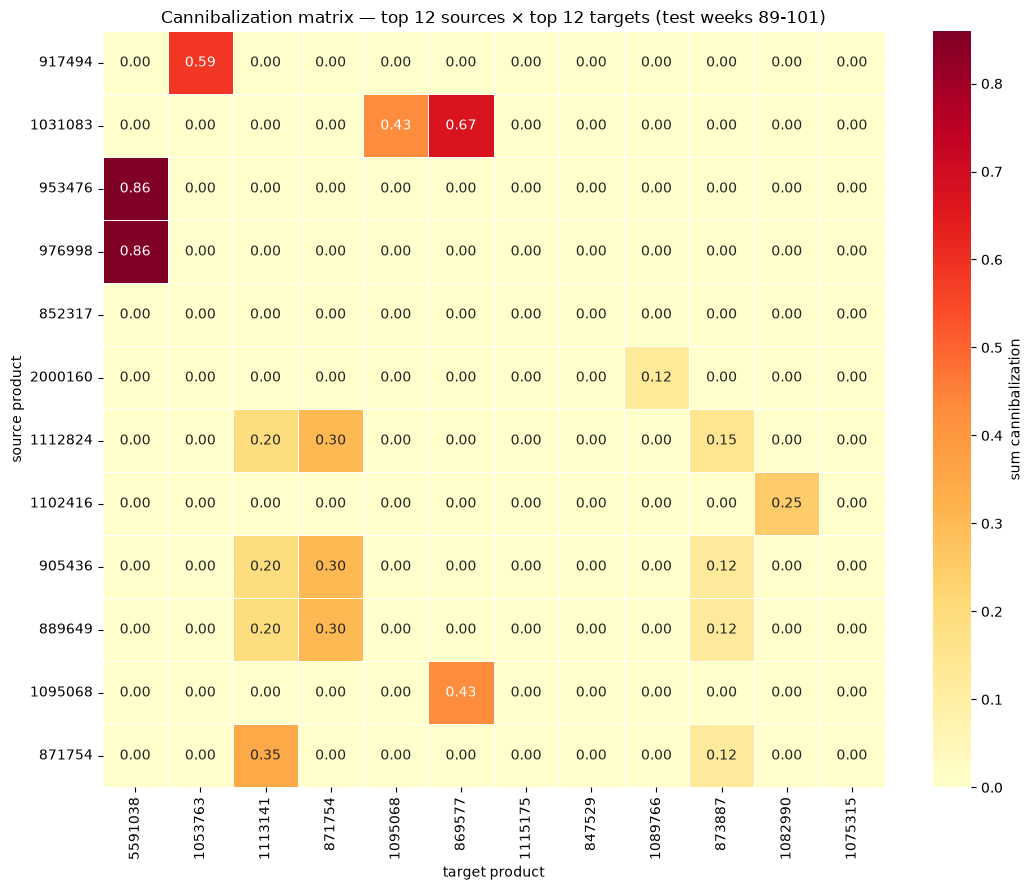

In [8]:
K = 12
srcs = matrix.groupby("source_product")["sum_cannibalization"].sum().nlargest(K).index
tgts = matrix.groupby("target_product")["sum_cannibalization"].sum().nlargest(K).index
grid = matrix.set_index(["source_product", "target_product"])["sum_cannibalization"].unstack(fill_value=0)
grid = grid.reindex(index=srcs, columns=tgts, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(grid, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "sum cannibalization"})
ax.set(title=f"Cannibalization matrix — top {K} sources × top {K} targets (test weeks {FIRST_TEST_WEEK}-{LAST_TEST_WEEK})",
       xlabel="target product", ylabel="source product")
plt.tight_layout()
fig.savefig(OUT / "cannibalization_matrix.png", dpi=140)
plt.show()

In [9]:
import shap

sample = test.sample(min(200 if SMOKE else 1200, len(test)), random_state=SEED)
explainer = shap.TreeExplainer(m)
sv_c = explainer.shap_values(sample[MODEL_FEATURES].assign(source_promo_flag=0))
sv_t = explainer.shap_values(sample[MODEL_FEATURES].assign(source_promo_flag=1))
contrib = (sv_t - sv_c).mean(axis=0)
drivers = pd.DataFrame({"feature": MODEL_FEATURES, "mean_effect_contribution": contrib}).sort_values(
    "mean_effect_contribution")
drivers.to_csv(OUT / "shap_cannibalization_drivers.csv", index=False)
print("mean E[y_treatment - y_control]:", round(float(contrib.sum()), 4))
print("top features increasing cannibalization (negative contribution):")
print(drivers.head(10).round(4).to_string(index=False))

mean E[y_treatment - y_control]: -0.0041
top features increasing cannibalization (negative contribution):
          feature  mean_effect_contribution
source_promo_flag                   -0.0050
         rmean4_B                   -0.0004
       src_emb_35                   -0.0002
       qty_lag1_B                   -0.0001
      resid_std_B                   -0.0001
       src_emb_37                   -0.0001
       src_emb_29                   -0.0001
       src_emb_63                   -0.0000
       src_emb_53                   -0.0000
     promo_freq_B                   -0.0000
